#### Imports

In [1]:
# Clone GitHub repository
!git clone https://github.com/Harshyadav430/DATA606-Capstone-Medical-Triage.git
!pip install streamlit

# Run to update pull requests
#!git pull https://github.com/Harshyadav430/DATA606-Capstone-Medical-Triage.git

# Basic Packages
import os
import pandas as pd

# Import src files from GitHub
os.chdir("DATA606-Capstone-Medical-Triage/src")
import triage_xgb as t_xgb
os.chdir("..")

# Mount Google Drive
from google.colab import drive

# ML Packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

import xgboost as xgb

Cloning into 'DATA606-Capstone-Medical-Triage'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 180 (delta 51), reused 35 (delta 35), pack-reused 127 (from 1)
Receiving objects: 100% (180/180), 1.35 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (84/84), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.9 MB/s eta 0:00:00


#### Mount Google Drive & Load Filtered Dataset

In [2]:
drive.mount('/content/drive') # mount drive
!cp "/content/drive/MyDrive/ATTRA/Yale_Dataset_Filtered.csv" . # load dataset, too large for GitHub

Mounted at /content/drive


#### EDA

In [3]:
# Sample original, filtered Yale School of Medicine dataset
df = pd.read_csv('Yale_Dataset_Filtered.csv', nrows=2)
df

,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,40,Male,Hispanic or Latino,White or Caucasian,English,NaN,Single,Full Time,Other,Discharge,...,0,0,0,0,0,0,0,0,0,0
1,66,Male,Hispanic or Latino,Native Hawaiian or Other Pacific Islander,English,Pentecostal,Married,Not Employed,Commercial,Discharge,...,0,0,0,0,0,0,0,0,0,0


### 1. Data Cleaning
> 1. Create dict for downcasted data types, e.g. Int64 to Int8, where feasible to reduce computing demand.
> 2. Replace NaN or delete rows with NaN.  Then, downgrade data types.


#### 1.1 - Create dict for downcasted data types

In [4]:
# Convert original feature data types and to dict.
dtypes_dict = dict(df.dtypes)
dtypes_dict.pop("disposition", None) # remove from dict to prevent error later
dtypes_dict

{'age': dtype('int64'),
 'gender': dtype('O'),
 'ethnicity': dtype('O'),
 'race': dtype('O'),
 'lang': dtype('O'),
 'religion': dtype('O'),
 'maritalstatus': dtype('O'),
 'employstatus': dtype('O'),
 'insurance_status': dtype('O'),
 'previousdispo': dtype('O'),
 'triage_vital_hr': dtype('int64'),
 'triage_vital_sbp': dtype('int64'),
 'triage_vital_dbp': dtype('int64'),
 'triage_vital_rr': dtype('int64'),
 'triage_vital_o2': dtype('float64'),
 'triage_vital_temp': dtype('int64'),
 'n_surgeries': dtype('int64'),
 'n_edvisits': dtype('int64'),
 'n_admissions': dtype('int64'),
 'cc_abdominalcramping': dtype('int64'),
 'cc_abdominaldistention': dtype('int64'),
 'cc_abdominalpain': dtype('int64'),
 'cc_abdominalpainpregnant': dtype('int64'),
 'cc_abnormallab': dtype('int64'),
 'cc_abscess': dtype('int64'),
 'cc_addictionproblem': dtype('int64'),
 'cc_agitation': dtype('int64'),
 'cc_alcoholintoxication': dtype('int64'),
 'cc_alcoholproblem': dtype('int64'),
 'cc_allergicreaction': dtype('int

In [5]:
# Save lists of features for future use
cc_features = [] # chief complaint (cc) features
triage_features = [] # features containing "vitals"

# Assign downcasted data types in dict.
for key in dtypes_dict:
  if key[0:3] == "cc_":
    cc_features.append(key) # make list of
    dtypes_dict[key] = "bool"
  elif key[0:2] == "n_":
    dtypes_dict[key] = "int32"
  elif key[0:7] == "triage_":
    triage_features.append(key)
    dtypes_dict[key] = "float64"

# Age feature
dtypes_dict['age'] = 'int8'

dtypes_dict

{'age': 'int8',
 'gender': dtype('O'),
 'ethnicity': dtype('O'),
 'race': dtype('O'),
 'lang': dtype('O'),
 'religion': dtype('O'),
 'maritalstatus': dtype('O'),
 'employstatus': dtype('O'),
 'insurance_status': dtype('O'),
 'previousdispo': dtype('O'),
 'triage_vital_hr': 'float64',
 'triage_vital_sbp': 'float64',
 'triage_vital_dbp': 'float64',
 'triage_vital_rr': 'float64',
 'triage_vital_o2': 'float64',
 'triage_vital_temp': 'float64',
 'n_surgeries': 'int32',
 'n_edvisits': 'int32',
 'n_admissions': 'int32',
 'cc_abdominalcramping': 'bool',
 'cc_abdominaldistention': 'bool',
 'cc_abdominalpain': 'bool',
 'cc_abdominalpainpregnant': 'bool',
 'cc_abnormallab': 'bool',
 'cc_abscess': 'bool',
 'cc_addictionproblem': 'bool',
 'cc_agitation': 'bool',
 'cc_alcoholintoxication': 'bool',
 'cc_alcoholproblem': 'bool',
 'cc_allergicreaction': 'bool',
 'cc_alteredmentalstatus': 'bool',
 'cc_animalbite': 'bool',
 'cc_ankleinjury': 'bool',
 'cc_anklepain': 'bool',
 'cc_anxiety': 'bool',
 'cc_ar

#### 1.2 - Handling NaN values and then downcast data types (dtypes)
 - Chunking data to prevent memory issues
 - Handling NaN in:
   - "cc_" features -> replace with 0/False
   - "religion" -> replace with "Unknown"  
   - "age" -> drop
   - "triage_" features -> drop
 - dtypes downcasted with dict made in previous step

In [6]:
# Check if clean file exists, remove if it does
filename = "Yale_Dataset_Filtered_Clean.csv"

if os.path.exists(filename):
    os.remove(filename)

# Chunk, downgrade data type, and fill records with NaN in "cc_" features.

chunksize = 100_000
first = True
total_rows = 0

for i, chunk in enumerate(pd.read_csv("Yale_Dataset_Filtered.csv", chunksize=chunksize)):
  # Count rows in each chunk
  print(f"Chunk {i}: {len(chunk)} rows")
  total_rows += len(chunk)

  # Rename "disposition" to "discharge":bool.  True for discharge, false for admission
  chunk.rename(columns={'disposition': 'discharge'}, inplace=True)
  chunk['discharge'] = chunk['discharge'] \
  .apply(lambda x: True if x == 'Discharge' else False) \
  .astype('bool')

  # Fill/drop NaN and downcast dtypes
  for col, dtype in dtypes_dict.items():
    if col in cc_features:
      chunk[col] = chunk[col].fillna(0) # Replace NaN with 0/False
    elif col == 'religion':
      chunk[col] = chunk[col].fillna('Unknown') # Replace NaN with 'Unknown'
    elif col == 'age':
      chunk.dropna(subset=['age'], inplace=True) # Drop records
    elif col in triage_features: # NaN in these values will make misleading results
      chunk.dropna(subset=[col], inplace=True) # Drop records

    chunk[col] = chunk[col].astype(dtype) # Change data types in df

  # Write cleaned chunk to disk immediately
  chunk.to_csv(filename, mode="a", header=first, index=False)
  first = False

print("Total rows:", total_rows)

Chunk 0: 100000 rows
Chunk 1: 100000 rows
Chunk 2: 100000 rows
Chunk 3: 100000 rows
Chunk 4: 100000 rows
Chunk 5: 60486 rows
Total rows: 560486


#### 1.3 - Load working dataset
 - Downcast some columns to categorical.  
 - Print number of rows lost in cleaning.


In [7]:
# Load dataset with downcasted dtypes and sample
df = pd.read_csv('Yale_Dataset_Filtered_Clean.csv')

# Downcast object to categorical.  Couldn't do this in previous step.
for col in ['gender','ethnicity','race','lang','religion','maritalstatus','employstatus','insurance_status','previousdispo']:
  df[col] = df[col].astype("category")

# Print number of rows remaining
print(df.shape)
print("rows removed:", total_rows - df.shape[0])

(271263, 220)
rows removed: 289223


#### 1.4 - Generate admission examples for testing

In [8]:
# Create admission cases for testing
df[df["discharge"]==False].sample().to_csv('admission_example4.csv')

#### 1.5 - Check for remaining NaN values in columns

In [9]:
# Checks if any "vital" features have NaN
df[
        df["triage_vital_hr"].isna()
        | df["triage_vital_sbp"].isna()
        | df["triage_vital_dbp"].isna()
        | df["triage_vital_rr"].isna()
        | df["triage_vital_o2"].isna()
        | df["triage_vital_temp"].isna()
].shape[0]

0

### 3. Training

#### 3.1 - Create train/split datasets

In [10]:
# Splitting dataset
X = df.drop("discharge", axis=1)
y = df["discharge"]

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=35, stratify=y
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=30, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(217010, 219) (27126, 219) (27127, 219)


#### 3.2 - Train the model

In [11]:
# Run
model = t_xgb.train_xgb_booster(X_train, X_val, y_train, y_val, 300)
best_auc = t_xgb.make_xgb_predictions(model, X_test, y_test, thresholds=[.35,.4,.45,.5,])

[0]	train-auc:0.76778	val-auc:0.76068
[1]	train-auc:0.78992	val-auc:0.78146
[2]	train-auc:0.79735	val-auc:0.78796
[3]	train-auc:0.80161	val-auc:0.79346
[4]	train-auc:0.80646	val-auc:0.79773
[5]	train-auc:0.81084	val-auc:0.80210
[6]	train-auc:0.81511	val-auc:0.80657
[7]	train-auc:0.81745	val-auc:0.80849
[8]	train-auc:0.82012	val-auc:0.81149
[9]	train-auc:0.82259	val-auc:0.81341
[10]	train-auc:0.82512	val-auc:0.81551
[11]	train-auc:0.82692	val-auc:0.81711
[12]	train-auc:0.82820	val-auc:0.81837
[13]	train-auc:0.82955	val-auc:0.81944
[14]	train-auc:0.83108	val-auc:0.82077
[15]	train-auc:0.83287	val-auc:0.82203
[16]	train-auc:0.83421	val-auc:0.82321
[17]	train-auc:0.83544	val-auc:0.82399
[18]	train-auc:0.83637	val-auc:0.82470
[19]	train-auc:0.83761	val-auc:0.82555
[20]	train-auc:0.83860	val-auc:0.82633
[21]	train-auc:0.83944	val-auc:0.82726
[22]	train-auc:0.84028	val-auc:0.82786
[23]	train-auc:0.84107	val-auc:0.82840
[24]	train-auc:0.84182	val-auc:0.82897
[25]	train-auc:0.84256	val-auc:0.82

#### 3.3 - Save model for later use

In [12]:
model.save_model(f"XGBoost_Triage_Model_AUC_{best_auc:2f}")

/tmp/ipykernel_4567/4005808830.py:1: UserWarning: [14:02:51] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(f"XGBoost_Triage_Model_AUC_{best_auc:2f}")


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4.  Feature Selection


#### 4.1 - Calculate information gain for each feature

In [14]:
# Print importances
feat_imp = t_xgb.get_importances(model)
feat_imp.head(20)

cc_alteredmentalstatus    173.461243
cc_shortnessofbreath      151.967758
cc_motorvehiclecrash      136.434036
cc_weakness               124.526260
cc_chestpain              108.004532
                             ...    
cc_footswelling             4.669035
cc_addictionproblem         4.649349
ethnicity                   4.322464
lang                        2.909415
cc_facialswelling           0.549385
Name: gain_importance, Length: 193, dtype: float64
(193,)


,gain_importance
cc_alteredmentalstatus,173.461243
cc_shortnessofbreath,151.967758
cc_motorvehiclecrash,136.434036
cc_weakness,124.526260
cc_chestpain,108.004532
cc_abdominalpain,104.502014
cc_syncope,96.109131
employstatus,95.024506
cc_abnormallab,92.952492
cc_psychiatricevaluation,92.442215


##### Observations:
> - Some chief complaint data contains little information gain.
> - Language is an obvious feature to remove.

In [15]:
# Print importances in ascending order
feat_imp.sort_values(ascending=True).head(10)

,gain_importance
cc_facialswelling,0.549385
lang,2.909415
ethnicity,4.322464
cc_addictionproblem,4.649349
cc_footswelling,4.669035
cc_femaleguproblem,4.814831
cc_hyperglycemia,5.206352
religion,5.316565
cc_mass,5.347800
cc_blurredvision,5.429649


Now, we will use recursive feature elimination to reduce number of features.

#### 4.2 - Recursive Feature Elimination (RFE)
- Generate a log of best AUC values as features are removed.
- Use log to graph "AUC vs. Number of Features Removed"

In [16]:
# Generate log
t_xgb.rfe_xgboost_booster(
    X_train, X_val, X_test, y_train, y_val, y_test, feat_imp, best_auc,
    elimination_log=None, max_loss=.02, min_features=192, thresh=.5)

Starting new log.
Number of Features (before elimination): 193

Trying removal: cc_facialswelling
Number of Features (after elimination): 192
[0]	train-auc:0.76778	val-auc:0.76068
[1]	train-auc:0.78992	val-auc:0.78146
[2]	train-auc:0.79735	val-auc:0.78796
[3]	train-auc:0.80161	val-auc:0.79346
[4]	train-auc:0.80646	val-auc:0.79773
[5]	train-auc:0.81084	val-auc:0.80210
[6]	train-auc:0.81511	val-auc:0.80657
[7]	train-auc:0.81745	val-auc:0.80849
[8]	train-auc:0.82012	val-auc:0.81149
[9]	train-auc:0.82259	val-auc:0.81341
[10]	train-auc:0.82512	val-auc:0.81551
[11]	train-auc:0.82692	val-auc:0.81711
[12]	train-auc:0.82820	val-auc:0.81837
[13]	train-auc:0.82955	val-auc:0.81944
[14]	train-auc:0.83108	val-auc:0.82077
[15]	train-auc:0.83287	val-auc:0.82203
[16]	train-auc:0.83420	val-auc:0.82321
[17]	train-auc:0.83543	val-auc:0.82399
[18]	train-auc:0.83637	val-auc:0.82471
[19]	train-auc:0.83761	val-auc:0.82555
[20]	train-auc:0.83860	val-auc:0.82634
[21]	train-auc:0.83944	val-auc:0.82726
[22]	train

##### AUC vs. Number of Features Removed

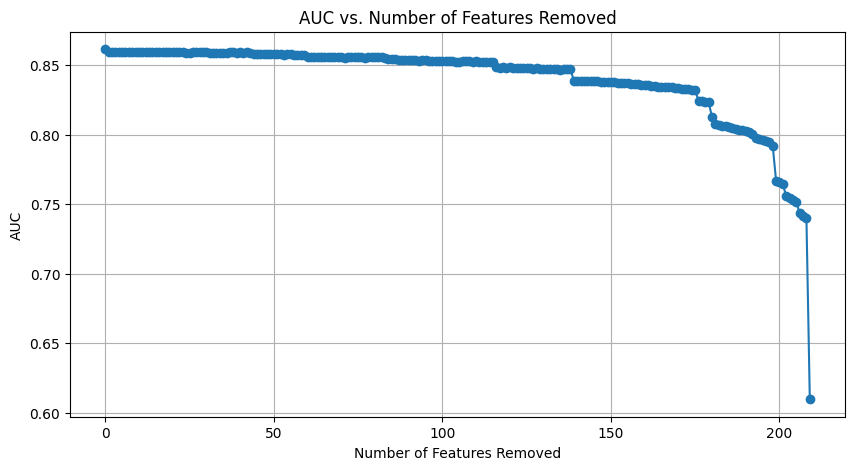

In [17]:
# Plot complete RFE graph
t_xgb.plot_auc('./data/triage/rfe_log_complete.csv') # saved, comprehensive log

#### 5. Integration with GUI
- Test how user input will be used against model in app
- List all unique values in dataset and use these as options for the user

In [18]:
# Take sample from training dataset
sample = X_train.sample(1)
# sample.to_csv("response_template.csv", index=False) #create response template for questionaire

# Predict discharge
t_xgb.predict_discharge(model, sample, thresh=.45)


discharged


(True, '59.65')

In [19]:
# Find all unique values for each column
df_unique_values_dict = {col: df[col].astype(str).unique() for col in df.columns}
df_unique_values_dict

# Save for creating questionnaire
pd.DataFrame(df_unique_values_dict.items()).to_csv("feature_unique_lists.csv", index=False)